In [1]:
# import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
# loading the dataset

diabetes = pd.read_csv(r"diabetes.csv")

In [3]:
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
diabetes.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [6]:
diabetes.shape

(768, 9)

In [7]:
# summary stats

diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
# convert zeros to NaN

cols_with_invalid_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
diabetes[cols_with_invalid_zeros] = diabetes[cols_with_invalid_zeros].replace(0, np.nan)

diabetes.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [9]:
# Impute missing values

cols_with_invalid_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_with_invalid_zeros:
    diabetes[col] = diabetes.groupby('Outcome')[col].transform(lambda x: x.fillna(x.median()))

diabetes.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [10]:
# EDA

diabetes['Outcome'].value_counts()
diabetes['Outcome'].value_counts(normalize=True) * 100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

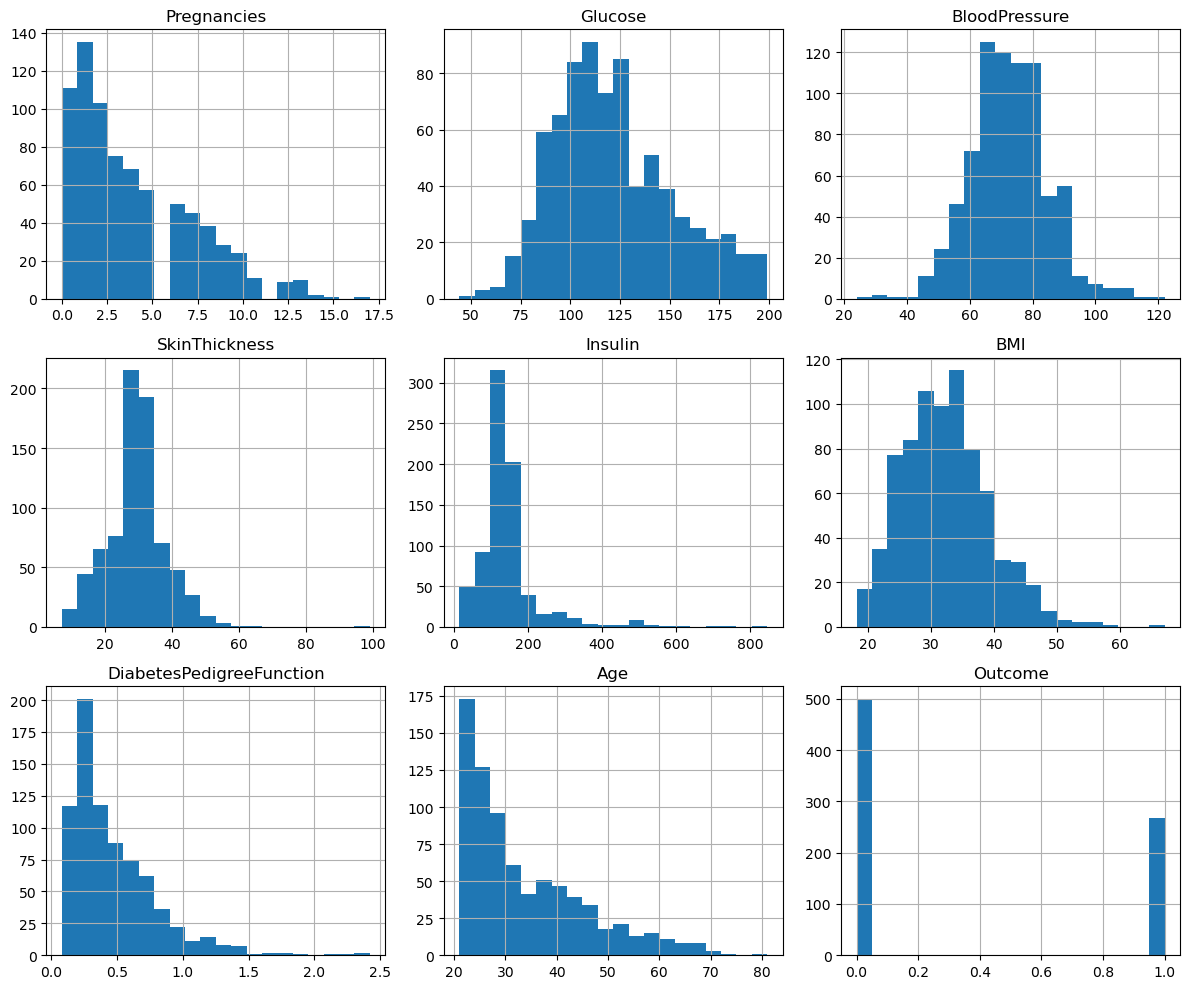

In [11]:
# Distribution Visualization

diabetes.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

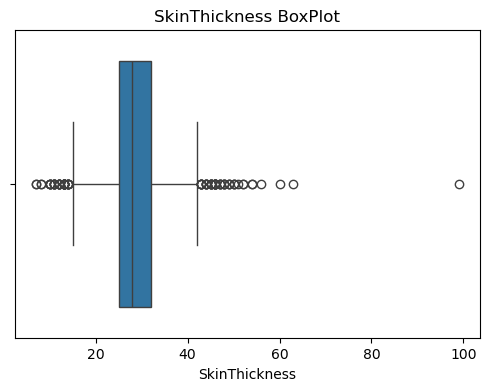

In [12]:
# checking for outliers

plt.figure(figsize=(6, 4))
sns.boxplot(x=diabetes['SkinThickness'])
plt.title('SkinThickness BoxPlot')
plt.show()


In [13]:
# Investigating Skinthickness 

diabetes[diabetes['SkinThickness'] > 80]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
579,2,197.0,70.0,99.0,169.5,34.7,0.575,62,1


In [14]:
# This patient's other values (high glucose, obese BMI, diabetic outcome, older age) 
# all paint a consistent picture of someone with poorly managed diabetes — and skinfold thickness 
# can genuinely be elevated in cases of obesity. So it's not glaringly inconsistent with the rest of the row... 
# but 99mm is still extreme even for that profile. 
# Typical clinical skinfold measurements rarely exceed 60mm regardless of BMI — the most likely explanation is still measurement/data-entry error
# (e.g., possibly should've been 29 or 39, or a stray extra digit), but we can't be 100% sure from the data alone.

In [15]:
# Capping the upper limit rather than deleting this row to avoid data loss

upper_limit = diabetes['SkinThickness'].quantile(0.99)
diabetes.loc[diabetes['SkinThickness'] > upper_limit, 'SkinThickness'] = upper_limit

diabetes['SkinThickness'].max()
    

51.33000000000004

In [16]:
# Correlation. Checking which features relates most to outcome

diabetes.corr()['Outcome'].sort_values(ascending=False)

Outcome                     1.000000
Glucose                     0.495990
Insulin                     0.377081
BMI                         0.315577
SkinThickness               0.299322
Age                         0.238356
Pregnancies                 0.221898
BloodPressure               0.174469
DiabetesPedigreeFunction    0.173844
Name: Outcome, dtype: float64

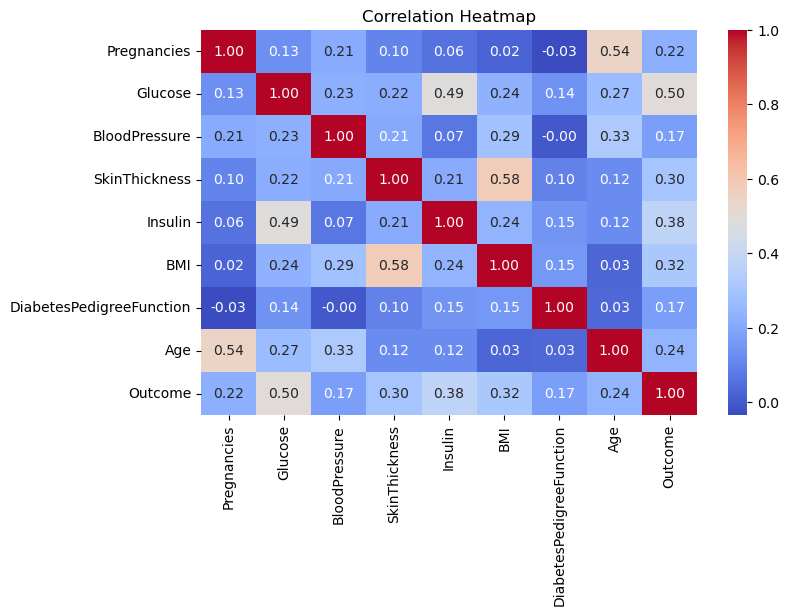

In [17]:
plt.figure(figsize=(8, 5))
corr = diabetes.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm',  fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

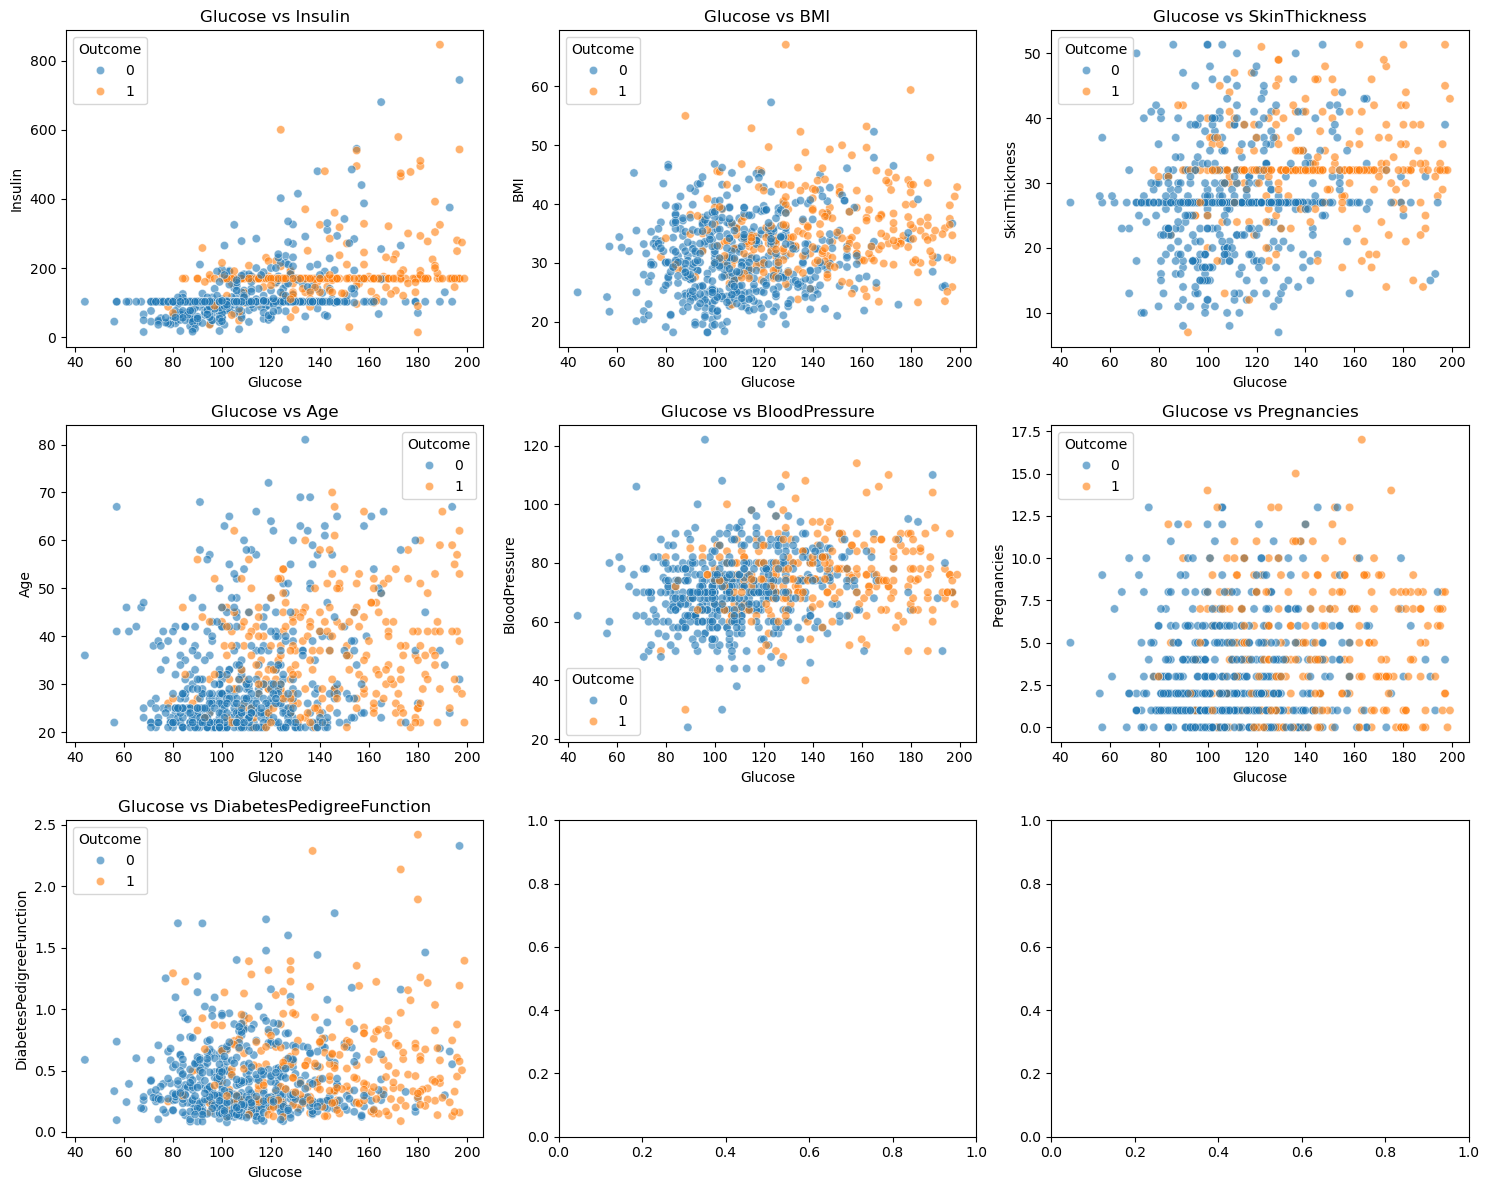

In [18]:
features = ['Insulin', 'BMI', 'SkinThickness', 'Age', 'BloodPressure', 'Pregnancies', 'DiabetesPedigreeFunction']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.scatterplot(data=diabetes, x='Glucose', y=feature, hue='Outcome', ax=axes[i], alpha=0.6)
    axes[i].set_title(f'Glucose vs {feature}')

plt.tight_layout()
plt.show()

In [19]:
# separating features

X = diabetes.drop('Outcome', axis=1)
y = diabetes['Outcome']


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(614, 8) (154, 8)
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


## ⚠️ Note on Data Leakage (Learning Note)

In this project, missing value imputation (grouped medians by `Outcome`) 
and outlier capping (SkinThickness Winsorization) were performed **before** 
the train/test split, using statistics computed from the **entire dataset**.

**Why this is technically data leakage:**
The test set is meant to simulate "unseen, real-world data." By calculating 
medians/percentiles using all 768 rows (including what became the test set), 
information from the test set indirectly influenced values in the training 
set — a small breach of the train/test boundary.

**Correct order for future projects:**
1. Split raw data into train/test FIRST
2. Fit any transformation (imputer, scaler, outlier caps, encoders) 
   ONLY on `X_train`
3. Apply that same

In [21]:
# Temporarily combine X_train and y_train so we can group by Outcome
train_temp = X_train.copy()
train_temp['Outcome'] = y_train

# Calculate group medians using ONLY training data
train_medians = train_temp.groupby('Outcome')[cols_with_invalid_zeros].median()
print(train_medians)

         Glucose  BloodPressure  SkinThickness  Insulin   BMI
Outcome                                                      
0          108.0           70.0           27.0    102.5  30.1
1          141.0           74.5           32.0    169.5  34.3


In [22]:
for outcome_value in [0, 1]:
    for col in cols_with_invalid_zeros:
        median_val = train_medians.loc[outcome_value, col]

        # Fill X_train
        mask_train = (y_train == outcome_value) & (X_train[col].isna())
        X_train.loc[mask_train, col] = median_val

        # Fill X_test
        mask_test = (y_test == outcome_value) & (X_test[col].isna())
        X_test.loc[mask_test, col] = median_val

print(X_train.isnull().sum())
print(X_test.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


In [23]:
# calculate the capping threshold using only X_train

upper_limit = X_train['SkinThickness'].quantile(0.99)

X_train.loc[X_train['SkinThickness'] > upper_limit, 'SkinThickness'] = upper_limit
X_test.loc[X_test['SkinThickness'] > upper_limit, 'SkinThickness'] = upper_limit

print(upper_limit)
print(X_train['SkinThickness'].max(), X_test['SkinThickness'].max())

50.0
50.0 50.0


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
# Logistic Regression model

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [26]:
# Predictions on the test set

y_pred = model.predict(X_test_scaled)

In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7078


In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[79 21]
 [24 30]]


In [29]:
# classification report

from sklearn.metrics import classification_report

model_balanced = LogisticRegression(random_state=42, class_weight='balanced')
model_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = model_balanced.predict(X_test_scaled)

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.86      0.73      0.79       100
           1       0.61      0.78      0.68        54

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.74       154
weighted avg       0.77      0.75      0.75       154



In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)  # note: using UNSCALED X_train, not X_train_scaled

y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.89      0.90      0.90       100
           1       0.81      0.80      0.80        54

    accuracy                           0.86       154
   macro avg       0.85      0.85      0.85       154
weighted avg       0.86      0.86      0.86       154



In [31]:
# Quick check for over fitting:

from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train, rf_model.predict(X_train))
test_acc = accuracy_score(y_test, rf_model.predict(X_test))

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Train Accuracy: 1.0000
Test Accuracy: 0.8636


In [32]:
# Model fine-tuning

rf_model_tuned = RandomForestClassifier(
    random_state=42, 
    class_weight='balanced',
    max_depth=5,
    min_samples_leaf=5
)
rf_model_tuned.fit(X_train, y_train)

train_acc_tuned = accuracy_score(y_train, rf_model_tuned.predict(X_train))
test_acc_tuned = accuracy_score(y_test, rf_model_tuned.predict(X_test))

print(f"Train Accuracy: {train_acc_tuned:.4f}")
print(f"Test Accuracy: {test_acc_tuned:.4f}")
print(classification_report(y_test, rf_model_tuned.predict(X_test)))

Train Accuracy: 0.9121
Test Accuracy: 0.8766
              precision    recall  f1-score   support

           0       0.93      0.88      0.90       100
           1       0.80      0.87      0.83        54

    accuracy                           0.88       154
   macro avg       0.86      0.88      0.87       154
weighted avg       0.88      0.88      0.88       154



Insulin                     0.421294
Glucose                     0.186046
SkinThickness               0.162589
BMI                         0.073673
Age                         0.065777
DiabetesPedigreeFunction    0.038440
Pregnancies                 0.026863
BloodPressure               0.025317
dtype: float64


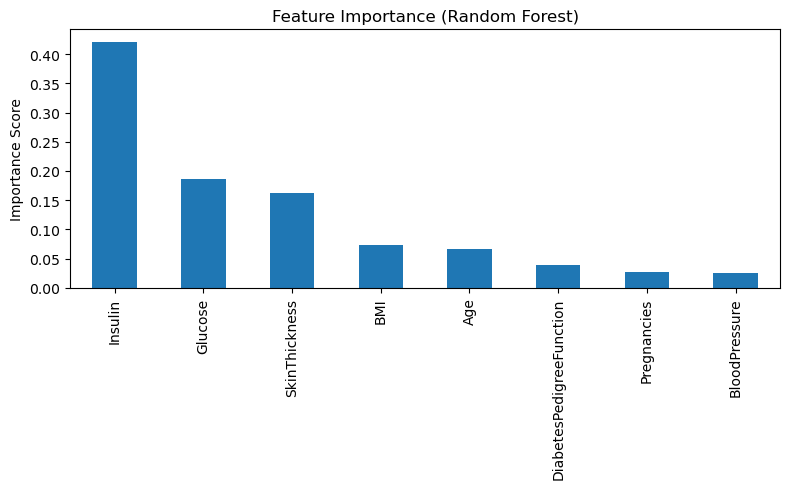

In [33]:
# Feature importance

import pandas as pd

importances = pd.Series(rf_model_tuned.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print(importances)

plt.figure(figsize=(8, 5))
importances.plot(kind='bar')
plt.title('Feature Importance (Random Forest)')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

In [34]:
# GridSearchCV — systematic hyperparameter tuning

from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_leaf': [3, 5, 10],
    'n_estimators': [100, 200]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='f1',  # optimize for F1 on class 1, not just accuracy
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-val F1 score:", grid_search.best_score_)

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
print(classification_report(y_test, y_pred_best))

Best parameters: {'max_depth': 7, 'min_samples_leaf': 5, 'n_estimators': 200}
Best cross-val F1 score: 0.833657727587819
              precision    recall  f1-score   support

           0       0.92      0.87      0.89       100
           1       0.78      0.85      0.81        54

    accuracy                           0.86       154
   macro avg       0.85      0.86      0.85       154
weighted avg       0.87      0.86      0.86       154



In [35]:
# Confusion matrix for the RandomForestClassifier Model after fine-Tuning

from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, rf_model_tuned.predict(X_test))
print(cm_rf)

[[88 12]
 [ 7 47]]


## Deploying 

In [36]:
# saving the model 

import joblib
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

# writing the trained model to a single file 
joblib.dump(rf_model_tuned, "model.pkl")


['model.pkl']

## Final Production Pipeline
Everything above was exploration. Below is the clean, deployment-ready pipeline that consolidates the final approach.

### Building custom Pipelines:



In [37]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

class ZeroToNaN(BaseEstimator, TransformerMixin):
    """Converts biologically invalid zeros to NaN for specified Coloumns"""
    def __init__(self, cols):
        self.cols = cols

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X[self.cols] = X[self.cols].replace(0, np.nan)
        return X


class SkinThicknessCapper(BaseEstimator, TransformerMixin):
    """Caps SkinThickness to the 99th percentile learnt from the trained data"""
    def __init__(self, col='SkinThickness', quantile=0.99):
        self.col = col
        self.quantile = quantile

    def fit(self, X, y=None):
        self.upper_limit_ =X[self.col].quantile(self.quantile)
        return self

    def transform(self, X):
        X = X.copy()
        X.loc[X[self.col] > self.upper_limit_, self.col] = self.upper_limit_
        return X

### Assembling the Full Pipeline



In [38]:
cols_with_invalid_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

pipeline = Pipeline([
    ('zero_to_nan', ZeroToNaN(cols=cols_with_invalid_zeros)),
    ('cap_skinthickness', SkinThicknessCapper()),
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        max_depth=5, min_samples_leaf=5,
        class_weight='balanced', random_state=42
    ))
])

### Fitting and Evaluate

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X = diabetes.drop('Outcome', axis=1)
y = diabetes['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.88      0.90       100
           1       0.80      0.87      0.83        54

    accuracy                           0.88       154
   macro avg       0.86      0.88      0.87       154
weighted avg       0.88      0.88      0.88       154



### Streamlit app

In [40]:
import joblib
joblib.dump(pipeline, "diabetes_pipeline.pkl")

['diabetes_pipeline.pkl']